### [Illuminate your ML models with Python and SHAP/PDP graphs](https://medium.com/top-python-libraries/illuminate-your-ml-models-with-python-and-shap-pdp-graphs-55ae5ff24407)

In [1]:
!pip install --quiet shap

In [2]:
!export MPLBACKEND=TKAgg

In [3]:
import os, sys
import matplotlib as mp

if "google.colab" not in sys.modules:
    mp.use('TKAgg')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn.utils import resample

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
plt.style.use('ggplot')

In [4]:
data_filepath = r"https://github.com/checkming00/Medium_datasets/raw/refs/heads/main/simulated_data2.csv" # Define the full path for the simulated data file to be loaded
target_column_name = 'target_variable' # The column name of the target variable in the CSV file

# --- Load Data ---
loaded_data_df = pd.read_csv(data_filepath) # Read the CSV file into a DataFrame
print(f"Data loaded successfully. Shape: {loaded_data_df.shape}") # Print the dimensions (shape) of the loaded data
print(f"Columns found: {loaded_data_df.columns.tolist()}") # Print a list of all column names

Data loaded successfully. Shape: (1000, 26)
Columns found: ['Avg Temperature', 'Max Temperature', 'Min Temperature', 'Precipitation', 'Solar Radiation', 'Wind Speed', 'Humidity', 'Evapotranspiration', 'Forest Cover', 'Urban Area', 'Cropland', 'Grassland', 'Water Body', 'Soil Organic Carbon', 'Soil pH', 'Clay Content', 'Silt Content', 'Sand Content', 'Soil Depth', 'Elevation', 'Slope', 'Aspect', 'Curvature', 'TWI', 'Roughness', 'target_variable']


In [5]:
display(loaded_data_df.sample(10))

,Avg Temperature,Max Temperature,Min Temperature,Precipitation,Solar Radiation,Wind Speed,Humidity,Evapotranspiration,Forest Cover,Urban Area,...,Silt Content,Sand Content,Soil Depth,Elevation,Slope,Aspect,Curvature,TWI,Roughness,target_variable
521,0.003511,0.040020,0.200851,0.186008,0.254759,0.304935,0.360065,0.420538,0.098866,0.042362,...,0.641119,0.953572,0.839624,0.426001,0.644717,0.177071,0.560522,0.981328,0.518315,-0.255899
737,0.394113,0.598503,0.374106,0.374948,0.133087,0.940747,0.750494,0.001243,0.765613,0.739795,...,0.153863,0.976416,0.242040,0.717692,0.143156,0.329013,0.442028,0.192232,0.449960,-1.206293
740,0.681177,0.372676,0.733315,0.405471,0.627607,0.769858,0.548216,0.539504,0.088234,0.410782,...,0.717299,0.395288,0.232594,0.342903,0.070965,0.331778,0.460742,0.955481,0.313411,0.024173
660,0.302049,0.713955,0.612047,0.427181,0.239026,0.369015,0.592107,0.350753,0.214896,0.116463,...,0.480781,0.924601,0.719690,0.111550,0.177704,0.787123,0.835851,0.545191,0.554455,-4.727630
411,0.480237,0.623742,0.830183,0.360463,0.430422,0.409518,0.374731,0.925529,0.828930,0.109000,...,0.007220,0.316596,0.677191,0.484039,0.978269,0.874104,0.359071,0.045487,0.845626,-3.454697
678,0.958286,0.083162,0.643641,0.972221,0.978224,0.471223,0.162749,0.202084,0.889601,0.911683,...,0.534002,0.236956,0.743888,0.473438,0.294792,0.801946,0.696714,0.937340,0.165442,2.970592
626,0.026030,0.237042,0.774190,0.240038,0.729103,0.251908,0.395292,0.983162,0.244812,0.376371,...,0.544250,0.032196,0.618922,0.055391,0.616356,0.685030,0.197768,0.819346,0.911085,-0.749152
513,0.195699,0.764564,0.023502,0.375497,0.110749,0.352475,0.173537,0.373305,0.417523,0.300591,...,0.571640,0.455011,0.149637,0.449727,0.278492,0.943163,0.884070,0.083903,0.516653,-1.780920
859,0.506758,0.318325,0.256691,0.020985,0.272955,0.449110,0.197950,0.087348,0.717728,0.894620,...,0.779366,0.725865,0.951884,0.738146,0.693210,0.261743,0.924769,0.179544,0.904897,0.172362
136,0.067256,0.094918,0.998893,0.326639,0.748184,0.806665,0.858023,0.997628,0.241496,0.040351,...,0.312778,0.654342,0.232018,0.014381,0.764353,0.623743,0.762303,0.038938,0.837120,-1.644156


In [6]:
display(loaded_data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Avg Temperature      1000 non-null   float64
 1   Max Temperature      1000 non-null   float64
 2   Min Temperature      1000 non-null   float64
 3   Precipitation        1000 non-null   float64
 4   Solar Radiation      1000 non-null   float64
 5   Wind Speed           1000 non-null   float64
 6   Humidity             1000 non-null   float64
 7   Evapotranspiration   1000 non-null   float64
 8   Forest Cover         1000 non-null   float64
 9   Urban Area           1000 non-null   float64
 10  Cropland             1000 non-null   float64
 11  Grassland            1000 non-null   float64
 12  Water Body           1000 non-null   float64
 13  Soil Organic Carbon  1000 non-null   float64
 14  Soil pH              1000 non-null   float64
 15  Clay Content         1000 non-null   fl

None

In [7]:
display(loaded_data_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Avg Temperature,1000.0,0.497550,0.290943,0.000227,0.256341,0.507346,0.757754,0.998561
Max Temperature,1000.0,0.475882,0.287749,0.000031,0.214286,0.475798,0.717885,0.999277
Min Temperature,1000.0,0.495106,0.293657,0.000012,0.243468,0.504402,0.745835,0.999505
Precipitation,1000.0,0.512949,0.281606,0.000943,0.292386,0.527475,0.757560,0.998793
Solar Radiation,1000.0,0.496494,0.291044,0.000135,0.240763,0.496137,0.751286,0.998698
Wind Speed,1000.0,0.504391,0.287854,0.000999,0.252158,0.492804,0.756410,0.998905
Humidity,1000.0,0.505550,0.285400,0.000410,0.251077,0.512791,0.752081,0.999718
Evapotranspiration,1000.0,0.505021,0.289969,0.000241,0.252002,0.503558,0.756563,0.998750
Forest Cover,1000.0,0.499187,0.287602,0.000158,0.248676,0.496895,0.746889,0.999656
Urban Area,1000.0,0.491232,0.281296,0.010567,0.250189,0.490452,0.724361,0.998198


In [8]:
# --- Define Features (X) and Target (y) from the loaded data ---
y = loaded_data_df[target_column_name] # Extract the target variable y
X = loaded_data_df.drop(columns=[target_column_name]) # Extract features X (all columns except the target variable column)
print(f"Features (X) shape: {X.shape}, Target (y) shape: {y.shape}") # Print the shapes of X and y

# --- Define/Confirm Feature Metadata (Should match feature columns in the CSV file) ---
real_feature_names = X.columns.tolist() # Directly get the list of feature names from the loaded X

# --- New Addition: Generate unique colors for each feature ---
num_total_features = len(real_feature_names)
# Use the nipy_spectral colormap to generate distinct colors for each feature.
# For fewer features (e.g., < 20), other colormaps like tab20 might be considered.
try:
    # Use plt.colormaps.get_cmap for modern matplotlib versions
    cmap = plt.colormaps.get_cmap('nipy_spectral')
    # Generate colors: ensures float division and handles the case of a single feature
    colors_list = [cmap(i / float(num_total_features - 1)) if num_total_features > 1 else cmap(0.5) for i in range(num_total_features)]
except AttributeError:
    # Fallback for older matplotlib versions
    import matplotlib.cm as cm
    colors_list = [cm.nipy_spectral(i / float(num_total_features - 1)) if num_total_features > 1 else cm.nipy_spectral(0.5) for i in range(num_total_features)]

# Create a dictionary mapping feature names to their generated colors
feature_color_palette = dict(zip(real_feature_names, colors_list))
print(f"Unique colors have been generated for {num_total_features} features.")

# Ensure the length of categories_for_names matches real_feature_names if CSV columns do not match expectations
units_for_names = { # Define a dictionary of units corresponding to each feature
    'Avg Temperature': '°C', 'Max Temperature': '°C', 'Min Temperature': '°C',
    'Precipitation': 'mm', 'Solar Radiation': 'W/m²', 'Wind Speed': 'm/s',
    'Humidity': '%', 'Evapotranspiration': 'mm',
    'Forest Cover': '%', 'Urban Area': '%', 'Cropland': '%',
    'Grassland': '%', 'Water Body': '%',
    'Soil Organic Carbon': 'g/kg', 'Soil pH': '', 'Clay Content': '%',
    'Silt Content': '%', 'Sand Content': '%', 'Soil Depth': 'cm',
    'Elevation': 'm', 'Slope': '°', 'Aspect': '°', 'Curvature': '',
    'TWI': '', 'Roughness': ''
}

if len(real_feature_names) != X.shape[1]: # Re-confirm if the number of features matches
    print(f"Warning: The number of loaded features ({X.shape[1]}) does not match the length of the 'real_feature_names' list ({len(real_feature_names)}).")

# Assign the feature name to unit mapping dictionary
feature_to_unit_map = units_for_names

Features (X) shape: (1000, 25), Target (y) shape: (1000,)
Unique colors have been generated for 25 features.


In [9]:
# --- Split Data and Train Model ---
print("Splitting data and training RandomForestRegressor model...") # Print message: starting data split and model training

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10, min_samples_leaf=5)
model.fit(X_train, y_train) # Fit the model using the training data
print("Model training complete.") # Print message that model training is finished

Splitting data and training RandomForestRegressor model...
Model training complete.


##### Calculating SHAP values using TreeExplainer

In [10]:
# --- Calculate SHAP Values (Panel A) ---
explainer = shap.TreeExplainer(model) # Create a TreeExplainer object
shap_values = explainer.shap_values(X_test) # Calculate SHAP values for the test set
print(f"SHAP values calculated successfully. Shape: {shap_values.shape}") # Print the shape of the SHAP values

mean_abs_shap = np.abs(shap_values).mean(axis=0) # Calculate the mean absolute SHAP value for each feature
shap_std = np.abs(shap_values).std(axis=0) # Calculate the standard deviation of the absolute SHAP values for each feature

# Create a DataFrame summarizing the SHAP values
shap_summary = pd.DataFrame({
    'feature': X_test.columns, # Feature names (from test set columns)
    'mean_abs_shap': mean_abs_shap, # Mean absolute SHAP value
    'shap_std_dev': shap_std # Standard deviation of SHAP values
})

# Sort by importance (mean absolute SHAP) in descending order
shap_summary = shap_summary.sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)
print("SHAP Value Summary (Top 5):") # Print summary message
display(shap_summary.head()) # Display the top 5 most important features

# Get data for Plot A (Feature Importance Plot)
features_plot_a_names_only = shap_summary['feature'].tolist() # Get the list of sorted feature names for Plot A
mean_shap_plot_a = shap_summary['mean_abs_shap'].values # Get the corresponding mean absolute SHAP values
ci_half_width_plot_a = shap_summary['shap_std_dev'].values # Get the corresponding standard deviation (used as error bar half-width)

# Create the list of feature names for display in Plot A (including units)
features_plot_a_display = [
    f"{name} ({feature_to_unit_map.get(name, '')})" if feature_to_unit_map.get(name) else name
    for name in features_plot_a_names_only
]
print("Data for Plot A is ready.") # Print message that Plot A data preparation is complete

SHAP values calculated successfully. Shape: (200, 25)
SHAP Value Summary (Top 5):


,feature,mean_abs_shap,shap_std_dev
0,Max Temperature,1.292910,0.226254
1,Min Temperature,1.031452,0.415932
2,Avg Temperature,0.701281,0.282695
3,Cropland,0.304110,0.140379
4,Precipitation,0.053100,0.030569


Data for Plot A is ready.


##### Calculate Partial Dependence Plot (PDP) Data (Panel B)

In [11]:
## Calculating partial dependence data for major features # Print message: Starting PDP data calculation

N_top_features = 6 # Define the number of top features for which to calculate PDP
# Get the names of the top features based on the SHAP summary (these are the original feature names)
top_features_for_pdp = shap_summary['feature'].head(N_top_features).tolist()

top_features_data_real = [] # Initialize list to store the PDP results
n_bootstrap_pdp = 25 # Number of bootstrap samples for PDP (can be reduced to speed up testing)
n_pdp_points = 50 # Number of grid points for the PDP curve

for i, feature_name_actual in enumerate(top_features_for_pdp): # Iterate through the top features
    # feature_category = feature_to_category_map.get(feature_name_actual, 'general') # Feature category (color no longer based on this)
    feature_unit = feature_to_unit_map.get(feature_name_actual, '') # Get the feature unit
    # Feature display name including the unit
    feature_name_with_unit_display = f"{feature_name_actual} ({feature_unit})" if feature_unit else feature_name_actual

    print(f"Processing PDP feature: {feature_name_with_unit_display} ({i + 1}/{N_top_features})...") # Print current PDP feature being processed

    bootstrap_lines = [] # Stores the PDP lines from bootstrap sampling
    pdp_values = None # The x-axis values for the PDP
    current_X_for_pdp = X_test # PDP is calculated based on the test set

    for j in range(n_bootstrap_pdp): # Perform bootstrap sampling
        # Bootstrap sample with replacement, keeping the DataFrame structure
        X_sample_df = resample(current_X_for_pdp, n_samples=len(current_X_for_pdp), random_state=42 + j)

        try: # Attempt to calculate PDP
            # Calculate partial dependence
            pdp_result = partial_dependence(
                model, # The trained model
                X_sample_df, # The sampled data
                features=[feature_name_actual], # Current feature name (as a string)
                kind='average', # Calculate the average effect
                grid_resolution=n_pdp_points, # Number of grid points
                response_method='auto' # Automatic response method
            )
            current_pdp_line = pdp_result['average'][0] # Get the PDP y-values
            bootstrap_lines.append(current_pdp_line) # Add to the list

            if pdp_values is None: # Only capture x-values from the first successful calculation
                pdp_values = pdp_result['values'][0] # Get the PDP x-values

        except Exception as e: # If calculation fails
            print(f"Warning: Bootstrap PDP calculation failed for feature {feature_name_actual}, sample {j}. Error: {e}") # Print warning
            continue # Continue to the next sample

    if not bootstrap_lines: # If no successful bootstrap lines were calculated
        print(f"Error: Could not calculate any PDP bootstrap lines for {feature_name_actual}. Skipping this feature.") # Print error
        continue # Skip this feature

    if pdp_values is None: # If x-axis values were not obtained
        print(f"Error: Could not obtain PDP x-axis values for {feature_name_actual}. Skipping this feature.") # Print error
        continue # Skip this feature

    average_line = np.mean(bootstrap_lines, axis=0) # Calculate the average PDP line

    top_features_data_real.append({ # Store the PDP results
        'name': feature_name_with_unit_display, # Display name (with unit)
        'original_name': feature_name_actual, # Store original feature name to get color
        # 'category': feature_category, # Category (color no longer based on this)
        'x': pdp_values, # x values
        'bootstrap': bootstrap_lines, # Bootstrap lines
        'average': average_line # Average line
    })

display(top_features_data_real)

print("Partial dependence data for Plot B is ready.") # Print message that Plot B data preparation is complete

Processing PDP feature: Max Temperature (°C) (1/6)...
Error: Could not obtain PDP x-axis values for Max Temperature. Skipping this feature.
Processing PDP feature: Min Temperature (°C) (2/6)...
Error: Could not obtain PDP x-axis values for Min Temperature. Skipping this feature.
Processing PDP feature: Avg Temperature (°C) (3/6)...
Error: Could not obtain PDP x-axis values for Avg Temperature. Skipping this feature.
Processing PDP feature: Cropland (%) (4/6)...
Error: Could not obtain PDP x-axis values for Cropland. Skipping this feature.
Processing PDP feature: Precipitation (mm) (5/6)...
Error: Could not obtain PDP x-axis values for Precipitation. Skipping this feature.
Processing PDP feature: Solar Radiation (W/m²) (6/6)...
Error: Could not obtain PDP x-axis values for Solar Radiation. Skipping this feature.


[]

Partial dependence data for Plot B is ready.


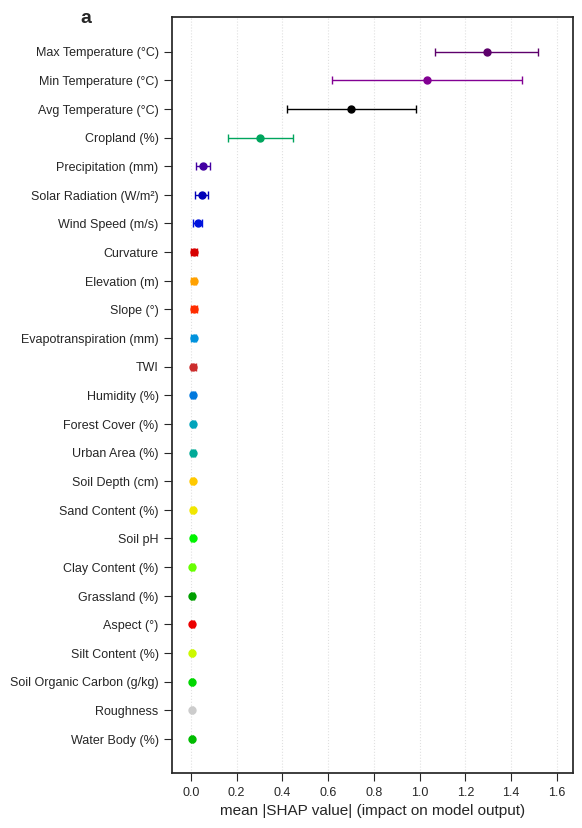

In [12]:
plt.style.use('seaborn-v0_8-ticks') # Use the seaborn style
fig = plt.figure(figsize=(14, 9)) # Create the figure

# Define the GridSpec layout
gs = gridspec.GridSpec(3, 3, figure=fig,
                        width_ratios=[1.5, 1, 1], # Column width ratios (SHAP, PDP_col1, PDP_col2)
                        wspace=0.25, # Column spacing
                        hspace=0.6) # Row spacing

# --- Panel A: Feature Contribution (SHAP) ---
ax_a = fig.add_subplot(gs[:, 0]) # SHAP plot occupies the first column (all rows)

n_features_a = len(features_plot_a_display) # Number of features in the SHAP plot
y_pos_a = np.arange(n_features_a) # Y-axis positions for the SHAP plot

# Plot error bars for each feature
for i in range(n_features_a):
    idx_a = n_features_a - 1 - i # Reverse index to put the most important feature at the top
    feature_name_for_color_a = features_plot_a_names_only[idx_a] # Get the original feature name to find the color
    color_a = feature_color_palette.get(feature_name_for_color_a, 'black') # Get the feature-specific color from the palette

    # Plot the error bar (mean_abs_shap as x-coordinate, y_pos as y-coordinate, std_dev as error)
    ax_a.errorbar(mean_shap_plot_a[idx_a], y_pos_a[i], xerr=ci_half_width_plot_a[idx_a],
                   fmt='o', color=color_a, capsize=3, lw=1, markersize=5, elinewidth=1)

# Calculate x-axis limit
valid_means_a = mean_shap_plot_a[np.isfinite(mean_shap_plot_a)] # Finite mean SHAP values

if len(valid_means_a) > 0: # If there are valid values
    upper_bounds_a = mean_shap_plot_a + ci_half_width_plot_a # Calculate upper bound of error bars
    valid_upper_bounds_a = upper_bounds_a[np.isfinite(upper_bounds_a)] # Finite upper bounds

    # Calculate the maximum end point of the error bar
    max_err_bar_end_a = np.max(valid_upper_bounds_a) if len(valid_upper_bounds_a) > 0 else np.max(valid_means_a)
    xlim_max_val_a = max_err_bar_end_a # Base value for x-axis maximum
    xlim_max_a = xlim_max_val_a * 1.1 if np.isfinite(xlim_max_val_a) else 1.0 # Add 10% margin
    if xlim_max_a <= 0 : xlim_max_a = 1.0 # Handle edge case
else: # If no valid values
    xlim_max_a = 1.0 # Default x-axis upper limit

ax_a.set_xlim(left=-0.05 * xlim_max_a, right=xlim_max_a) # Set x-axis range
ax_a.grid(True, axis='x', linestyle=':', color='lightgray', alpha=0.7) # X-axis grid lines
ax_a.grid(False, axis='y') # Do not display y-axis grid lines

ax_a.set_yticks(y_pos_a) # Set y-axis ticks
ax_a.set_yticklabels(features_plot_a_display[::-1], fontsize=9) # Set y-axis labels (reversed to match plot)
ax_a.set_xlabel('mean |SHAP value| (impact on model output)', fontsize=11) # Set x-axis label

# Ensure all four spines are visible (often hidden by default in some styles)
ax_a.spines['top'].set_visible(True)
ax_a.spines['right'].set_visible(True)
ax_a.spines['bottom'].set_visible(True)
ax_a.spines['left'].set_visible(True)

ax_a.tick_params(axis='x', which='major', labelsize=9) # X-axis tick font size

# Panel 'a' label
ax_a.text(-0.20, 1.01, 'a', transform=ax_a.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# --- Panel B: Partial Dependence Plots (PDP) ---
axes_b = [] # List of Axes objects for PDP subplots

if not top_features_data_real: # If no PDP data was calculated
    print("Warning: No PDP data was successfully calculated. Panel B will be empty.")
else: # If there is PDP data
    for i_row_b in range(3): # Iterate through rows for PDP subplots
        for j_col_b in range(2): # Iterate through columns for PDP subplots
            plot_idx_b = i_row_b * 2 + j_col_b # Current PDP subplot index
            # Ensure the index does not exceed the data quantity or the max features defined
            if plot_idx_b < len(top_features_data_real) and plot_idx_b < N_top_features:
                # Create PDP subplot (starting from the second column of GridSpec)
                ax_b = fig.add_subplot(gs[i_row_b, j_col_b + 1])
                axes_b.append(ax_b) # Add to the list

all_pdp_y_values_b = [] # Collect all PDP y-values to unify the y-axis

for i_b, pdp_data_item_b in enumerate(top_features_data_real): # Iterate through PDP data for each feature
    if i_b >= len(axes_b): break # Stop if exceeding the created subplots
    ax_b_current = axes_b[i_b] # Get the current subplot Axes

    if 'x' not in pdp_data_item_b or pdp_data_item_b['x'] is None or len(pdp_data_item_b['x']) == 0: # Check x-values
        ax_b_current.set_title(f"{pdp_data_item_b.get('name', 'Error')}\n(X Data Missing)", fontsize=9, color='red') # Display error
        continue # Skip this feature

    x_coords_pdp_b = pdp_data_item_b['x'] # PDP x-coordinates
    valid_bootstrap_lines_for_avg_b = [] # Valid bootstrap lines for calculating the average

    if 'bootstrap' in pdp_data_item_b and pdp_data_item_b['bootstrap']: # If bootstrap data exists
        for line_data_b in pdp_data_item_b['bootstrap']: # Iterate through each line
            # Check for validity (not None and length matches x-coordinates)
            if line_data_b is not None and len(x_coords_pdp_b) == len(line_data_b):
                # Plot bootstrap line
                ax_b_current.plot(x_coords_pdp_b, line_data_b, color='silver', linewidth=0.8, alpha=0.5)
                finite_line_data_b = line_data_b[np.isfinite(line_data_b)] # Valid data points
                if finite_line_data_b.size > 0: # If points exist
                    all_pdp_y_values_b.extend(finite_line_data_b) # Add to the list
                    valid_bootstrap_lines_for_avg_b.append(line_data_b) # Add to the list for average calculation

    avg_line_to_plot_b = pdp_data_item_b.get('average') # Get the pre-calculated average line
    if avg_line_to_plot_b is None and valid_bootstrap_lines_for_avg_b: # If average line is missing but bootstrap lines exist
        avg_line_to_plot_b = np.mean(valid_bootstrap_lines_for_avg_b, axis=0) # Re-calculate the average line

    if avg_line_to_plot_b is not None and len(x_coords_pdp_b) == len(avg_line_to_plot_b): # If average line is valid
        original_feature_name_for_color_b = pdp_data_item_b['original_name'] # Get original feature name
        avg_line_color_b = feature_color_palette.get(original_feature_name_for_color_b, 'black') # Get feature-specific color
        ax_b_current.plot(x_coords_pdp_b, avg_line_to_plot_b, color=avg_line_color_b, linewidth=2.0) # Plot the average line
        finite_avg_line_b = avg_line_to_plot_b[np.isfinite(avg_line_to_plot_b)] # Valid data points
        if finite_avg_line_b.size > 0: # If points exist
            all_pdp_y_values_b.extend(finite_avg_line_b) # Add to the list
    else: # If the average line cannot be plotted
        ax_b_current.text(0.5, 0.5, 'Average Line Missing', horizontalalignment='center', # Display hint
                          verticalalignment='center', transform=ax_b_current.transAxes, color='red', fontsize=8)

    ax_b_current.set_title(pdp_data_item_b['name'], fontsize=10) # Set subplot title
    ax_b_current.grid(True, linestyle=':', color='lightgray', alpha=0.7) # Grid lines
    ax_b_current.spines['top'].set_visible(False) # Hide top border
    ax_b_current.spines['right'].set_visible(False) # Hide right border
    ax_b_current.tick_params(axis='both', which='major', labelsize=8) # Tick font size

if all_pdp_y_values_b and axes_b: # If there are y-values and subplots
    y_min_pdp_b, y_max_pdp_b = np.min(all_pdp_y_values_b), np.max(all_pdp_y_values_b) # Calculate y-axis range
    # Calculate a buffer (10% of the range, or a default 0.1 if range is too small)
    pdp_buffer_b = (y_max_pdp_b - y_min_pdp_b) * 0.1 if (y_max_pdp_b - y_min_pdp_b) > 1e-6 else 0.1
    final_y_min_pdp_b = y_min_pdp_b - pdp_buffer_b # Final y-axis minimum
    final_y_max_pdp_b = y_max_pdp_b + pdp_buffer_b # Final y-axis maximum
    for ax_b_item_b in axes_b: # Iterate through PDP subplots
        ax_b_item_b.set_ylim(final_y_min_pdp_b, final_y_max_pdp_b) # Set unified y-axis range
elif axes_b: # If there are subplots but no y-values
    print("Warning: No valid Y values found across all PDP plots. Cannot automatically set unified Y-axis range.")

y_label_pdp_text = 'Predicted Output' # PDP y-axis label
x_label_pdp_text = 'Feature Value' # PDP x-axis label
if axes_b: # If PDP subplots were created
    num_pdp_cols_b = 2 # Number of PDP columns
    num_pdp_axes_b = len(axes_b) # Total number of PDP subplots
    for idx_b, ax_b_item_b in enumerate(axes_b): # Iterate through PDP subplots
        if idx_b % num_pdp_cols_b == 0: # If it's a subplot in the first column
            ax_b_item_b.set_ylabel(y_label_pdp_text, fontsize=10) # Set y-axis label
        if idx_b >= num_pdp_axes_b - num_pdp_cols_b : # If it's a subplot in the last row
            ax_b_item_b.set_xlabel(x_label_pdp_text, fontsize=10) # Set x-axis label
    # Panel 'b' label (placed relative to the top-left PDP subplot)
    axes_b[0].text(-0.35, 1.18, 'b', transform=axes_b[0].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

plt.subplots_adjust(left=0.18, right=0.96, top=0.92, bottom=0.08) # Adjust overall layout

plt.show() # Display the figure
